In [33]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import linear_rainbow
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator

import contextlib
import io
with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    from preprocessing import ndf, survey_variables

## Setup

In [34]:
ALPHA5 = 0.05
ALPHA1 = 0.01

gender_unique = sorted(ndf["gender"].unique())

ndf["gender_labels"] = ndf["gender"].map({
    gender_unique[0]: "Female",
    gender_unique[1]: "Male"
})

main_vars = list(survey_variables.keys())
eco_facs = list(survey_variables["economical"])
cul_facs = list(survey_variables["cultural"])
soc_facs = list(survey_variables["social"])

## Normality overview

In [35]:
def norm_test(col, alpha=ALPHA5):
    """Test normality and return 1 for normal, otherwise 0."""
    col = np.asarray(col)

    if len(col) >= 30:
        test = stats.kstest(col, "norm", args=(np.mean(col), np.std(col)))
    else:
        test = stats.shapiro(col)

    return 1 if test.pvalue >= alpha else 0


numeric_cols = [
    c for c in ndf.select_dtypes(include=np.number).columns
    if c != "ID"
]

normal_cols, non_normal_cols = [], []

for col in numeric_cols:
    (normal_cols if norm_test(ndf[col]) else non_normal_cols).append(col)

max_len = max(len(normal_cols), len(non_normal_cols))

normality_df = pd.DataFrame({
    "Normal": normal_cols + ["-"] * (max_len - len(normal_cols)),
    "Non-normal": non_normal_cols + ["-"] * (max_len - len(non_normal_cols))
}).T

## Difference between main variables

In [36]:
def bh_correct(pvals, alpha=ALPHA5):
    """Apply Benjamini-Hochberg FDR correction."""
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)

    if n == 0:
        return np.array([]), np.array([], dtype=bool)

    order = np.argsort(pvals)
    ranked = pvals[order]

    adjusted = ranked * n / (np.arange(n) + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    adjusted = np.clip(adjusted, 0, 1)

    out = np.empty(n)
    out[order] = adjusted

    return out, out <= alpha


main_var_data = ndf[
    ["economical", "cultural", "social"]
].dropna()

scores = [
    main_var_data["economical"],
    main_var_data["cultural"],
    main_var_data["social"]
]

# Check normality of each score
normality_results = {
    "economical": norm_test(main_var_data["economical"]),
    "cultural": norm_test(main_var_data["cultural"]),
    "social": norm_test(main_var_data["social"])
}

all_normal = all(normality_results.values())

# Check sphericity using the variances of pairwise differences
diff_ec = main_var_data["economical"] - main_var_data["cultural"]
diff_es = main_var_data["economical"] - main_var_data["social"]
diff_cs = main_var_data["cultural"] - main_var_data["social"]

levene_stat, levene_p = stats.levene(
    diff_ec,
    diff_es,
    diff_cs
)

variance_homogeneous = levene_p >= ALPHA5

print("Normality:")
print(normality_results)

print(f"\nVariance homogeneity test: p = {levene_p:.4f}")

if all_normal and variance_homogeneous:

    # Repeated-measures ANOVA
    from statsmodels.stats.anova import AnovaRM

    anova_data = main_var_data.reset_index(drop=True)

    anova_long = anova_data.reset_index().melt(
        id_vars="index",
        var_name="Variable",
        value_name="Score"
    )

    anova_long = anova_long.rename(
        columns={"index": "Subject"}
    )

    rm_anova = AnovaRM(
        anova_long,
        depvar="Score",
        subject="Subject",
        within=["Variable"]
    ).fit()

    print("\nRepeated-measures ANOVA:")
    print(rm_anova)

    anova_table = rm_anova.anova_table
    omnibus_p = anova_table["Pr > F"].iloc[0]
    omnibus_stat = anova_table["F Value"].iloc[0]

    main_var_method = "Repeated-measures ANOVA"

else:

    # Friedman test
    friedman_stat, friedman_p = stats.friedmanchisquare(
        *scores
    )

    omnibus_stat = friedman_stat
    omnibus_p = friedman_p
    main_var_method = "Friedman test"

    print("\nFriedman test:")
    print(f"Statistic = {friedman_stat:.4f}")
    print(f"P-value = {friedman_p:.4f}")

Normality:
{'economical': 1, 'cultural': 1, 'social': 1}

Variance homogeneity test: p = 0.3334

Repeated-measures ANOVA:
                Anova
         F Value Num DF  Den DF Pr > F
--------------------------------------
Variable  3.9768 2.0000 60.0000 0.0239



## Post-hoc pairwise comparisons

In [37]:
main_var_pairs = [
    ("economical", "cultural"),
    ("economical", "social"),
    ("cultural", "social")
]

posthoc_results = []

if omnibus_p < ALPHA5:

    for var_a, var_b in main_var_pairs:

        if all_normal and variance_homogeneous:

            stat_val, p_val = stats.ttest_rel(
                main_var_data[var_a],
                main_var_data[var_b]
            )

            method = "Paired t-test"

        else:

            stat_val, p_val = stats.wilcoxon(
                main_var_data[var_a],
                main_var_data[var_b]
            )

            method = "Wilcoxon signed-rank"

        posthoc_results.append({
            "Comparison": f"{var_a} vs {var_b}",
            "Method": method,
            "Statistic": round(stat_val, 4),
            "P-value": p_val
        })

    main_var_df = pd.DataFrame(posthoc_results)

    main_var_df["P (FDR)"], main_var_df["Significant (FDR)"] = bh_correct(
        main_var_df["P-value"]
    )

else:

    main_var_df = pd.DataFrame({
        "Comparison": [],
        "Method": [],
        "Statistic": [],
        "P-value": [],
        "P (FDR)": [],
        "Significant (FDR)": []
    })

## Results

In [38]:
print("\n================ Main Variable Analysis ================")
print(f"Method: {main_var_method}")
print(f"Statistic: {omnibus_stat:.4f}")
print(f"P-value: {omnibus_p:.4f}")

if omnibus_p < ALPHA5:
    print("\nPost-hoc comparisons:")
    print(main_var_df)
else:
    print("\nThe omnibus test was not significant.")
    print("No post-hoc pairwise comparisons were performed.")


================ Main Variable Analysis ================
Method: Repeated-measures ANOVA
Statistic: 3.9768
P-value: 0.0239

Post-hoc comparisons:
               Comparison         Method  Statistic   P-value   P (FDR)  \
0  economical vs cultural  Paired t-test    -3.3966  0.001941  0.005822   
1    economical vs social  Paired t-test    -1.6396  0.111541  0.167311   
2      cultural vs social  Paired t-test     0.8407  0.407169  0.407169   

   Significant (FDR)  
0               True  
1              False  
2              False  


## Plot differences between main variables

E:\PycharmProjects\PythonProject\social-status\.venv\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


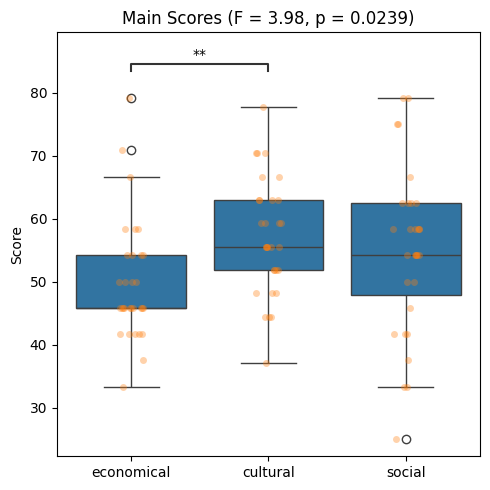

In [39]:
main_plot_df = ndf[
    ["economical", "cultural", "social"]
].melt(
    var_name="Variable",
    value_name="Score"
)

plt.figure(figsize=(5, 5))

ax = sns.boxplot(
    data=main_plot_df,
    x="Variable",
    y="Score"
)

sns.stripplot(
    data=main_plot_df,
    x="Variable",
    y="Score",
    alpha=0.35,
    jitter=True
)

pairs = [
    ("economical", "cultural"),
    ("economical", "social"),
    ("cultural", "social")
]

if omnibus_p < ALPHA5:

    annotator = Annotator(
        ax,
        pairs,
        data=main_plot_df,
        x="Variable",
        y="Score"
    )

    annotator.set_pvalues(
        main_var_df["P (FDR)"].tolist()
    )

    annotator.configure(
        test=None,
        text_format="star",
        loc="inside",
        hide_non_significant=True,
        verbose=0
    )

    annotator.annotate()

if main_var_method == "Repeated-measures ANOVA":
    title = f"Main Scores (F = {omnibus_stat:.2f}, p = {omnibus_p:.4f})"
else:
    title = f"Main Scores (χ² = {omnibus_stat:.2f}, p = {omnibus_p:.4f})"

ax.set_title(title)
ax.set_xlabel("")
ax.set_ylabel("Score")

plt.tight_layout()

plt.savefig(
    r"E:\PycharmProjects\PythonProject\social-status\1-output-figures\scores.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Correlation matrix

In [40]:
def linearity_test(x, y, alpha=ALPHA5):
    """Test whether the relationship between two variables is linear."""
    try:
        x = np.asarray(x, dtype=float)
        y = np.asarray(y, dtype=float)

        order = np.argsort(x)
        x_sorted = x[order]
        y_sorted = y[order]

        model = sm.OLS(
            y_sorted,
            sm.add_constant(x_sorted)
        ).fit()

        _, p = linear_rainbow(model)

        return p >= alpha

    except Exception:
        return True


def test_corr(x, y):
    """Calculate Pearson or Spearman correlation."""
    both_normal = norm_test(x) and norm_test(y)

    if both_normal and linearity_test(x, y):
        r, p = stats.pearsonr(x, y)
        return r, p, "Pearson"

    r, p = stats.spearmanr(x, y)
    return r, p, "Spearman"


def correlation_ci(r, n, alpha=ALPHA5):
    """Calculate a Fisher z confidence interval for a correlation."""
    if n <= 3 or abs(r) >= 1:
        return np.nan, np.nan

    z = np.arctanh(r)
    se = 1 / np.sqrt(n - 3)
    z_crit = stats.norm.ppf(1 - alpha / 2)

    return (
        np.tanh(z - z_crit * se),
        np.tanh(z + z_crit * se)
    )


def mixed_corr_matrix(df):
    """Calculate pairwise correlations, p-values, and methods."""
    cols = df.columns

    corr = pd.DataFrame(
        np.eye(len(cols)),
        index=cols,
        columns=cols
    )

    pvals = pd.DataFrame(
        np.ones((len(cols), len(cols))),
        index=cols,
        columns=cols
    )

    methods = pd.DataFrame(
        "-",
        index=cols,
        columns=cols
    )

    for i, col_a in enumerate(cols):
        for col_b in cols[i + 1:]:
            r, p, method = test_corr(
                df[col_a],
                df[col_b]
            )

            corr.loc[col_a, col_b] = r
            corr.loc[col_b, col_a] = r

            pvals.loc[col_a, col_b] = p
            pvals.loc[col_b, col_a] = p

            methods.loc[col_a, col_b] = method
            methods.loc[col_b, col_a] = method

    return corr, pvals, methods


def fdr_significant_pairs(pval_matrix):
    """Return pairwise correlations significant after BH-FDR correction."""
    cols = pval_matrix.columns
    pairs = []
    raw_pvals = []

    for i, col_a in enumerate(cols):
        for col_b in cols[i + 1:]:
            pairs.append((col_a, col_b))
            raw_pvals.append(pval_matrix.loc[col_a, col_b])

    _, sig_mask = bh_correct(raw_pvals)

    return [
        pair
        for pair, significant in zip(pairs, sig_mask)
        if significant
    ]


var_mat, var_pvals, var_methods = mixed_corr_matrix(
    ndf[main_vars]
)

eco_mat, eco_pvals, eco_methods = mixed_corr_matrix(
    ndf[eco_facs]
)

cul_mat, cul_pvals, cul_methods = mixed_corr_matrix(
    ndf[cul_facs]
)

soc_mat, soc_pvals, soc_methods = mixed_corr_matrix(
    ndf[soc_facs]
)


for i, col_a in enumerate(main_vars):
    for col_b in main_vars[i + 1:]:
        r = var_mat.loc[col_a, col_b]

        ci_lo, ci_hi = correlation_ci(
            r,
            len(ndf)
        )

        print(
            f"{col_a} vs {col_b}: "
            f"r={r:.3f}, 95% CI=[{ci_lo:.3f}, {ci_hi:.3f}] "
            f"({var_methods.loc[col_a, col_b]})"
        )

economical vs cultural: r=0.234, 95% CI=[-0.131, 0.543] (Pearson)
economical vs social: r=-0.072, 95% CI=[-0.416, 0.290] (Pearson)
cultural vs social: r=0.229, 95% CI=[-0.136, 0.540] (Pearson)


## Correlation matrices

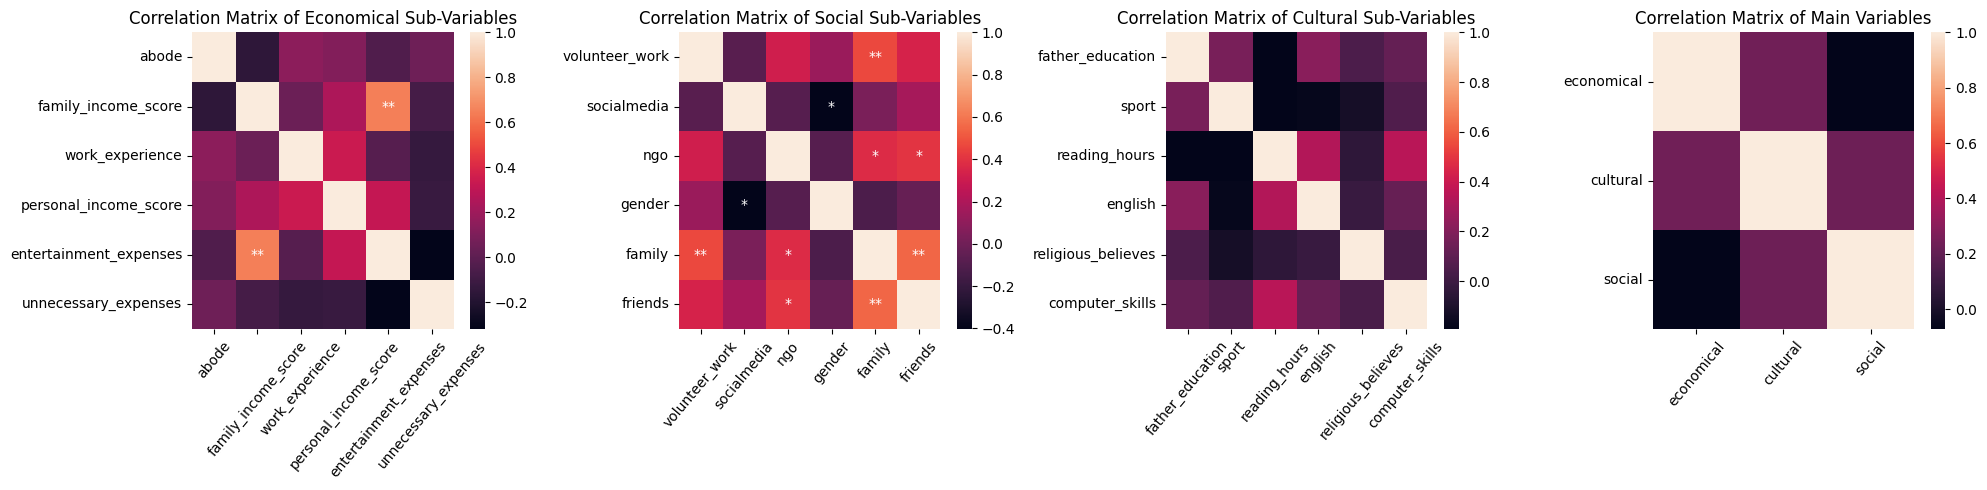

In [41]:
def correlation_annotations(pvals):
    """Create significance stars from a p-value matrix."""
    return np.select(
        [
            pvals.values < ALPHA1,
            pvals.values < ALPHA5
        ],
        [
            "**",
            "*"
        ],
        default=""
    )


corr_matrices = [
    (
        eco_mat,
        eco_pvals,
        "Correlation Matrix of Economical Sub-Variables"
    ),
    (
        soc_mat,
        soc_pvals,
        "Correlation Matrix of Social Sub-Variables"
    ),
    (
        cul_mat,
        cul_pvals,
        "Correlation Matrix of Cultural Sub-Variables"
    ),
    (
        var_mat,
        var_pvals,
        "Correlation Matrix of Main Variables"
    )
]

fig, axes = plt.subplots(
    1,
    4,
    figsize=(20, 5)
)

for ax, (corr, pvals, title) in zip(
    axes,
    corr_matrices
):
    sns.heatmap(
        corr,
        annot=correlation_annotations(pvals),
        fmt="s",
        ax=ax
    )

    ax.set_title(title)
    ax.tick_params(
        axis="x",
        rotation=50
    )
    ax.tick_params(
        axis="y",
        rotation=0
    )

plt.tight_layout()

plt.savefig(
    r"E:\PycharmProjects\PythonProject\social-status\1-output-figures\correlation_matrices.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Scatter plots and distributions

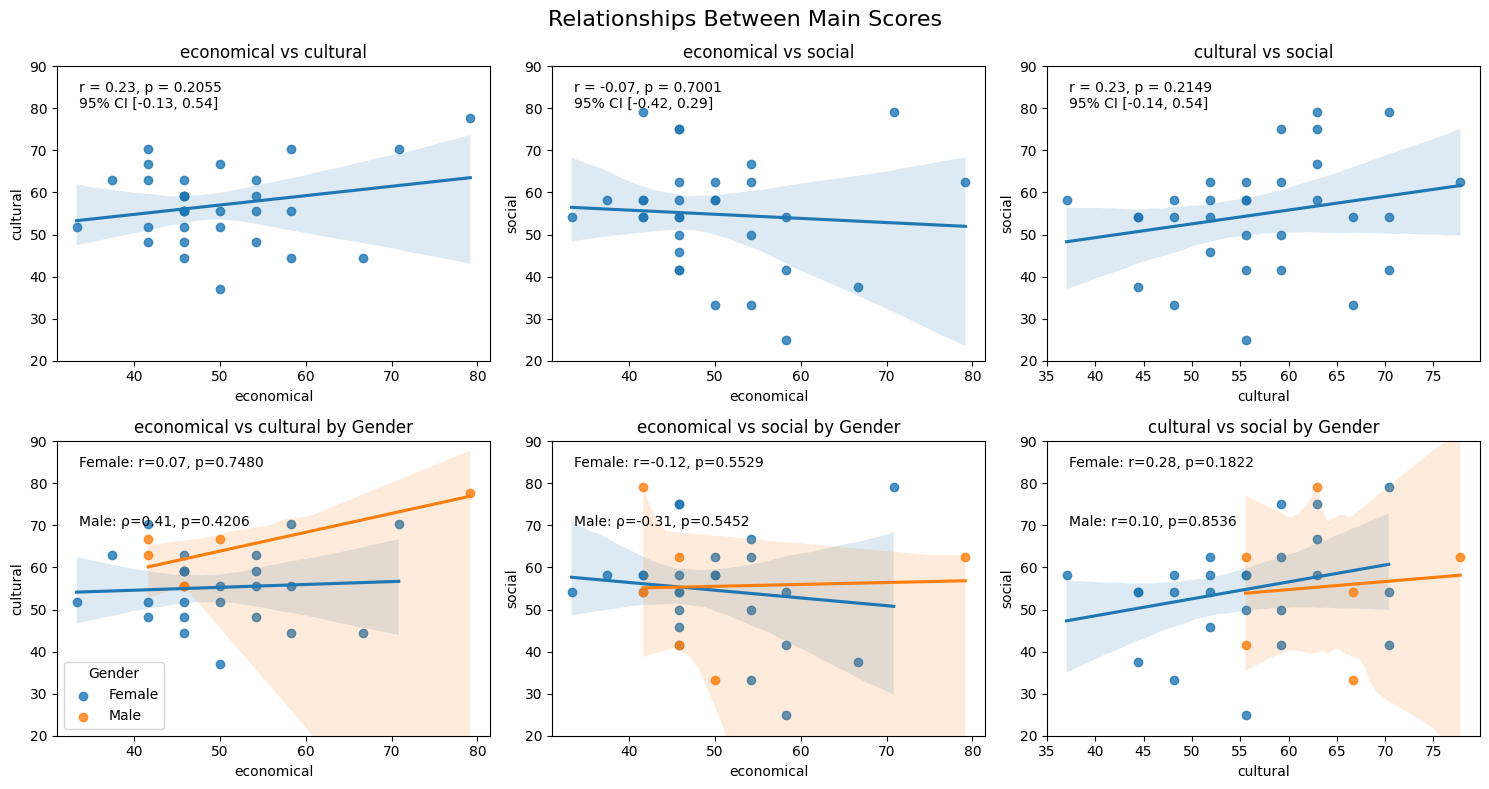

In [42]:
axis_pairs = [
    ("economical", "cultural"),
    ("economical", "social"),
    ("cultural", "social")
]

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 8)
)

axes = axes.flatten()

for i, (x_var, y_var) in enumerate(axis_pairs):

    sns.regplot(
        data=ndf,
        x=x_var,
        y=y_var,
        ax=axes[i]
    )

    r, p, method = test_corr(
        ndf[x_var],
        ndf[y_var]
    )

    ci_lo, ci_hi = correlation_ci(
        r,
        len(ndf)
    )

    label = "r" if method == "Pearson" else "ρ"

    axes[i].text(
        0.05,
        0.95,
        f"{label} = {r:.2f}, p = {p:.4f}\n"
        f"95% CI [{ci_lo:.2f}, {ci_hi:.2f}]",
        transform=axes[i].transAxes,
        va="top"
    )

    axes[i].set_title(
        f"{x_var} vs {y_var}"
    )


for i, (x_var, y_var) in enumerate(axis_pairs):

    for gender_label in ["Female", "Male"]:

        subset = ndf[
            ndf["gender_labels"] == gender_label
        ]

        sns.regplot(
            data=subset,
            x=x_var,
            y=y_var,
            ax=axes[i + 3],
            label=gender_label
        )

        r, p, method = test_corr(
            subset[x_var],
            subset[y_var]
        )

        ci_lo, ci_hi = correlation_ci(
            r,
            len(subset)
        )

        label = "r" if method == "Pearson" else "ρ"

        axes[i + 3].text(
            0.05,
            0.95 if gender_label == "Female" else 0.75,
            f"{gender_label}: {label}={r:.2f}, p={p:.4f}",
            transform=axes[i + 3].transAxes,
            va="top"
        )

    axes[i + 3].set_title(
        f"{x_var} vs {y_var} by Gender"
    )


axes[3].legend(title="Gender")

fig.suptitle(
    "Relationships Between Main Scores",
    fontsize=16
)

for ax in axes.flatten():
    ax.set_ylim([20, 90])

plt.tight_layout()

plt.savefig(
    r"E:\PycharmProjects\PythonProject\social-status\1-output-figures\score_regplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Scores across genders

In [43]:
score_df = pd.DataFrame({
    "Gender": ndf["gender_labels"],
    "ECO": ndf["economical"],
    "CUL": ndf["cultural"],
    "SOC": ndf["social"],
    "Overall": ndf["overall"]
})

fem_score = score_df[
    score_df["Gender"] == "Female"
]

men_score = score_df[
    score_df["Gender"] == "Male"
]

## Check assumptions

In [44]:
main_gender_vars = ["ECO", "CUL", "SOC"]

main_normal = True
overall_normal = True
main_equal_var = True
overall_equal_var = True


for col in main_gender_vars:

    if not norm_test(fem_score[col]):
        main_normal = False

    if not norm_test(men_score[col]):
        main_normal = False

    _, levene_p = stats.levene(
        fem_score[col],
        men_score[col]
    )

    if levene_p < ALPHA5:
        main_equal_var = False


if not norm_test(fem_score["Overall"]):
    overall_normal = False

if not norm_test(men_score["Overall"]):
    overall_normal = False

_, overall_levene_p = stats.levene(
    fem_score["Overall"],
    men_score["Overall"]
)

if overall_levene_p < ALPHA5:
    overall_equal_var = False


# Select tests for Annotator

if main_normal and main_equal_var:
    main_test = "t-test_ind"
else:
    main_test = "Mann-Whitney"

if overall_normal and overall_equal_var:
    overall_test = "t-test_ind"
else:
    overall_test = "Mann-Whitney"


print("ECO/CUL/SOC test:", main_test)
print("Overall test:", overall_test)

ECO/CUL/SOC test: Mann-Whitney
Overall test: Mann-Whitney


## Gender score plot

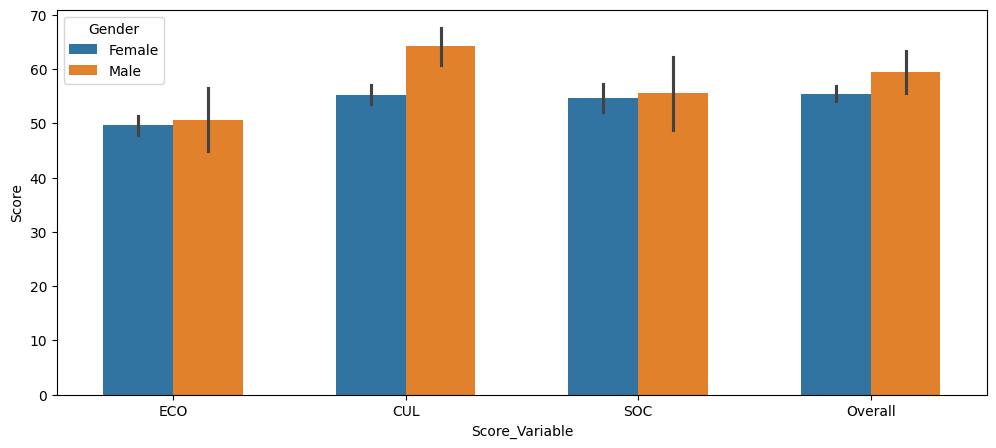

In [45]:
score_df_melted = score_df.melt(
    id_vars="Gender",
    var_name="Score_Variable",
    value_name="Score"
)

plt.figure(figsize=(12, 5))

ax = sns.barplot(
    data=score_df_melted,
    x="Score_Variable",
    y="Score",
    hue="Gender",
    errorbar="se",
    width=0.6
)

## ECO/CUL/SOC comparisons

In [46]:
main_pairs = [
    (("ECO", "Female"), ("ECO", "Male")),
    (("CUL", "Female"), ("CUL", "Male")),
    (("SOC", "Female"), ("SOC", "Male"))
]

main_annotator = Annotator(
    ax,
    main_pairs,
    data=score_df_melted,
    x="Score_Variable",
    y="Score",
    hue="Gender"
)

main_annotator.configure(
    test=main_test,
    text_format="star",
    loc="inside",
    hide_non_significant=True,
    comparisons_correction="BH",
    verbose=1
)

main_annotator.apply_and_annotate()

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04



(<Axes: xlabel='Score_Variable', ylabel='Score'>,
  <statannotations.Annotation.Annotation at 0x2928e351710>])

<Figure size 640x480 with 0 Axes>

## Overall comparison

In [47]:
overall_pair = [
    (("Overall", "Female"), ("Overall", "Male"))
]

overall_annotator = Annotator(
    ax,
    overall_pair,
    data=score_df_melted,
    x="Score_Variable",
    y="Score",
    hue="Gender"
)

overall_annotator.configure(
    test=overall_test,
    text_format="star",
    loc="inside",
    hide_non_significant=True,
    verbose=1
)

overall_annotator.apply_and_annotate()

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04



(<Axes: xlabel='Score_Variable', ylabel='Score'>,
 [<statannotations.Annotation.Annotation at 0x2928ba51090>])

<Figure size 640x480 with 0 Axes>

## Figure settings

In [48]:
ax.set_title("Mean Scores by Gender")
ax.set_xlabel("Score Variable")
ax.set_ylabel("Mean Score")
ax.set_ylim(0, 100)

plt.tight_layout()

plt.savefig(
    r"E:\PycharmProjects\PythonProject\social-status\1-output-figures\score_gender.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

## Cross sub-scale correlations

In [49]:
def mixed_cross_corr(vars_a, vars_b):
    """Calculate correlations between two sets of variables."""
    corr = pd.DataFrame(
        index=vars_a.columns,
        columns=vars_b.columns,
        dtype=float
    )

    pvals = pd.DataFrame(
        index=vars_a.columns,
        columns=vars_b.columns,
        dtype=float
    )

    methods = pd.DataFrame(
        index=vars_a.columns,
        columns=vars_b.columns,
        dtype=object
    )

    for col_a in vars_a.columns:
        for col_b in vars_b.columns:

            r, p, method = test_corr(
                vars_a[col_a],
                vars_b[col_b]
            )

            corr.loc[col_a, col_b] = r
            pvals.loc[col_a, col_b] = p
            methods.loc[col_a, col_b] = method

    return corr, pvals, methods


eco_soc_corr, eco_soc_pvals, eco_soc_methods = mixed_cross_corr(
    ndf[eco_facs],
    ndf[soc_facs]
)

eco_cul_corr, eco_cul_pvals, eco_cul_methods = mixed_cross_corr(
    ndf[eco_facs],
    ndf[cul_facs]
)

soc_cul_corr, soc_cul_pvals, soc_cul_methods = mixed_cross_corr(
    ndf[soc_facs],
    ndf[cul_facs]
)

## Cross-correlation matrices

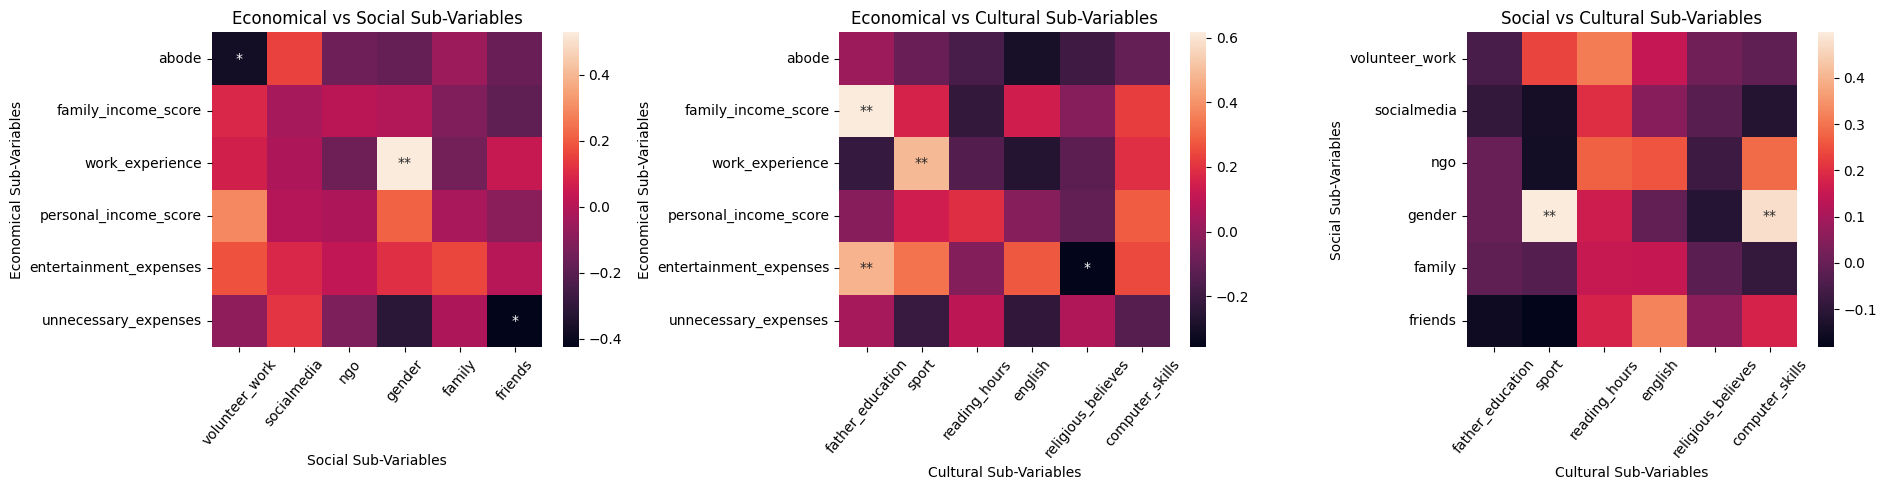

In [50]:
cross_corr_matrices = [
    (
        eco_soc_corr,
        eco_soc_pvals,
        "Economical vs Social Sub-Variables",
        "Social Sub-Variables",
        "Economical Sub-Variables"
    ),
    (
        eco_cul_corr,
        eco_cul_pvals,
        "Economical vs Cultural Sub-Variables",
        "Cultural Sub-Variables",
        "Economical Sub-Variables"
    ),
    (
        soc_cul_corr,
        soc_cul_pvals,
        "Social vs Cultural Sub-Variables",
        "Cultural Sub-Variables",
        "Social Sub-Variables"
    )
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(19, 5)
)

for ax, (
    corr,
    pvals,
    title,
    xlabel,
    ylabel
) in zip(
    axes,
    cross_corr_matrices
):

    sns.heatmap(
        corr.astype(float),
        annot=correlation_annotations(pvals),
        fmt="s",
        ax=ax
    )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    ax.tick_params(
        axis="x",
        rotation=50
    )

    ax.tick_params(
        axis="y",
        rotation=0
    )

plt.tight_layout()

plt.savefig(
    r"E:\PycharmProjects\PythonProject\social-status\1-output-figures\cross_correlation_matrices.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()